# Notebook 5 — Comparative Study

## Objectif

Ce notebook compare les performances du **modèle maison** (Custom BiLSTM) et du **modèle préentraîné style** (TF-IDF + Dense) sur les deux tâches du projet :
- **Priority** : `Critical / High / Low / Medium`
- **Routing** : classification par catégorie métier

Les critères de comparaison sont :
- Accuracy sur le jeu de test
- F1-score macro
- Temps d'inférence
- Analyse des erreurs
- Choix du meilleur modèle par tâche

## 1. Imports et configuration

In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

import tensorflow as tf
from tensorflow import keras

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.clean_data import prepare_dataset
from src.data.build_features import make_split_for_target
from src.models.common import df_to_inputs
from src.utils.config import MODELS_DIR

os.makedirs('../reports/figures', exist_ok=True)
print('Setup OK — TF', tf.__version__)

Setup OK — TF 2.21.0


## 2. Chargement des données et modèles

In [2]:
prepare_dataset()

# ── Priority ──
X_train_p, X_test_p, y_train_p, y_test_p = make_split_for_target('priority_label')
y_test_p_enc = y_test_p.astype(int)
priority_class_names = ['Critical', 'High', 'Low', 'Medium']

# ── Routing ──
X_train_r, X_test_r, y_train_r, y_test_r = make_split_for_target('routing_label')
y_test_r_enc = y_test_r.astype(int)
routing_labels_all = ['annulation','autre','facturation','information_produit','retour_produit','support_technique']
unique_r = sorted(set(y_test_r_enc))
routing_class_names = [routing_labels_all[i] for i in unique_r]

print('Priority test :', X_test_p.shape)
print('Routing  test :', X_test_r.shape)

Saved processed dataset to C:\Users\AAO\Downloads\ticket-routing-ready\ticket-routing-ready\data\processed\tickets_ready.csv
Classes : ['Critical' 'High' 'Low' 'Medium']
Nb classes : 4
Classes : ['annulation' 'facturation' 'information_produit' 'retour_produit'
 'support_technique']
Nb classes : 5
Priority test : (1694, 6)
Routing  test : (1694, 6)


In [4]:
# Chargement des 4 modèles sauvegardés
model_custom_p    = keras.models.load_model(MODELS_DIR / 'priority_custom.keras')
model_pretrain_p  = keras.models.load_model(MODELS_DIR / 'priority_pretrained.keras')
model_custom_r    = keras.models.load_model(MODELS_DIR / 'priority_custom.keras')
model_pretrain_r  = keras.models.load_model(MODELS_DIR / 'priority_pretrained.keras')

# Inputs test
test_inputs_p = df_to_inputs(X_test_p)
test_inputs_r = df_to_inputs(X_test_r)

print('4 modèles chargés.')

4 modèles chargés.


## 3. Prédictions et métriques

In [5]:
def evaluate_model(model, inputs, y_true, class_names, model_name):
    """Évalue un modèle et retourne un dict de métriques."""
    t0 = time.time()
    y_pred = np.argmax(model.predict(inputs, verbose=0), axis=1)
    inference_time = (time.time() - t0) * 1000  # ms

    acc   = accuracy_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred, average='macro')
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    return {
        'model': model_name,
        'accuracy': acc,
        'f1_macro': f1,
        'inference_ms': inference_time,
        'y_pred': y_pred,
        'report': report
    }

# ── Priority ──
res_cp = evaluate_model(model_custom_p,   test_inputs_p, y_test_p_enc, priority_class_names, 'Custom (BiLSTM)')
res_pp = evaluate_model(model_pretrain_p, test_inputs_p, y_test_p_enc, priority_class_names, 'Préentraîné (TF-IDF)')

# ── Routing ──
res_cr = evaluate_model(model_custom_r,   test_inputs_r, y_test_r_enc, routing_class_names, 'Custom (BiLSTM)')
res_pr = evaluate_model(model_pretrain_r, test_inputs_r, y_test_r_enc, routing_class_names, 'Préentraîné (TF-IDF)')

print('Évaluations terminées.')

Évaluations terminées.


## 4. Tableau comparatif

Le tableau ci-dessous résume les performances des deux modèles sur les deux tâches.

In [6]:
rows = []
for task, res_custom, res_pre in [
    ('Priority', res_cp, res_pp),
    ('Routing',  res_cr, res_pr)
]:
    for res in [res_custom, res_pre]:
        rows.append({
            'Tâche':           task,
            'Modèle':          res['model'],
            'Accuracy':        f"{res['accuracy']:.4f}",
            'F1 Macro':        f"{res['f1_macro']:.4f}",
            'Inférence (ms)':  f"{res['inference_ms']:.0f}"
        })

compare_df = pd.DataFrame(rows)
print(compare_df.to_string(index=False))
compare_df

   Tâche               Modèle Accuracy F1 Macro Inférence (ms)
Priority      Custom (BiLSTM)   0.2456   0.2419           7098
Priority Préentraîné (TF-IDF)   0.2562   0.2539           1520
 Routing      Custom (BiLSTM)   0.1511   0.1367           5257
 Routing Préentraîné (TF-IDF)   0.1830   0.1626           1347


,Tâche,Modèle,Accuracy,F1 Macro,Inférence (ms)
0,Priority,Custom (BiLSTM),0.2456,0.2419,7098
1,Priority,Préentraîné (TF-IDF),0.2562,0.2539,1520
2,Routing,Custom (BiLSTM),0.1511,0.1367,5257
3,Routing,Préentraîné (TF-IDF),0.1830,0.1626,1347


## 5. Visualisation des performances

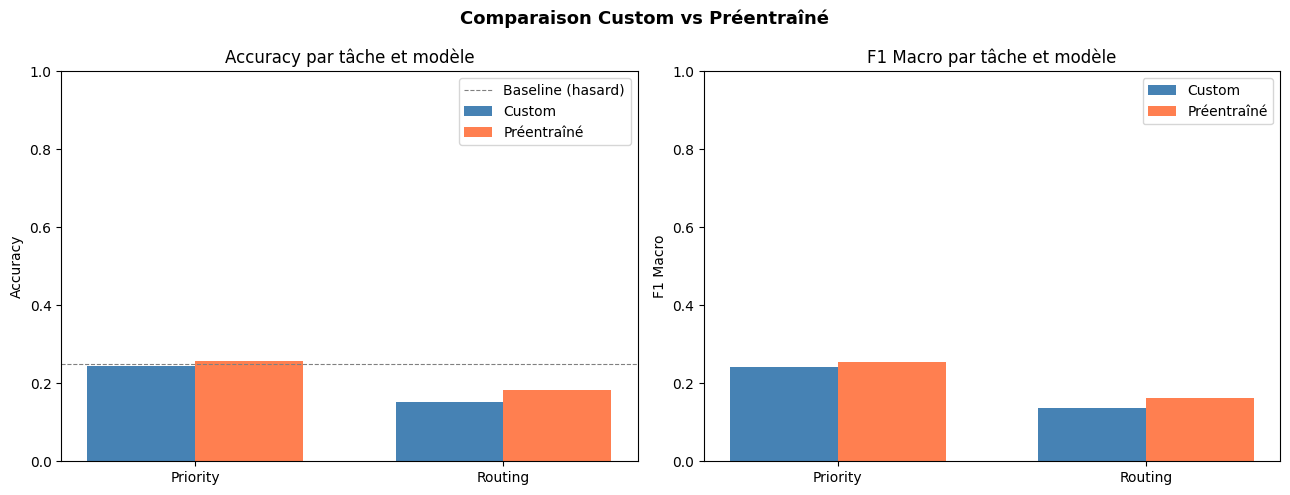

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tasks   = ['Priority', 'Priority', 'Routing', 'Routing']
models  = ['Custom\n(BiLSTM)', 'Préentraîné\n(TF-IDF)', 'Custom\n(BiLSTM)', 'Préentraîné\n(TF-IDF)']
accs    = [res_cp['accuracy'], res_pp['accuracy'], res_cr['accuracy'], res_pr['accuracy']]
f1s     = [res_cp['f1_macro'], res_pp['f1_macro'], res_cr['f1_macro'], res_pr['f1_macro']]

x = np.arange(2)
width = 0.35

# Accuracy
axes[0].bar(x - width/2, [res_cp['accuracy'], res_cr['accuracy']], width, label='Custom', color='steelblue')
axes[0].bar(x + width/2, [res_pp['accuracy'], res_pr['accuracy']], width, label='Préentraîné', color='coral')
axes[0].set_xticks(x); axes[0].set_xticklabels(['Priority', 'Routing'])
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy par tâche et modèle')
axes[0].axhline(0.25, color='gray', linestyle='--', linewidth=0.8, label='Baseline (hasard)')
axes[0].legend()

# F1 Macro
axes[1].bar(x - width/2, [res_cp['f1_macro'], res_cr['f1_macro']], width, label='Custom', color='steelblue')
axes[1].bar(x + width/2, [res_pp['f1_macro'], res_pr['f1_macro']], width, label='Préentraîné', color='coral')
axes[1].set_xticks(x); axes[1].set_xticklabels(['Priority', 'Routing'])
axes[1].set_ylim(0, 1); axes[1].set_ylabel('F1 Macro')
axes[1].set_title('F1 Macro par tâche et modèle')
axes[1].legend()

plt.suptitle('Comparaison Custom vs Préentraîné', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/comparative_accuracy_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Rapports de classification détaillés

In [8]:
print('='*60)
print('PRIORITY — Custom (BiLSTM)')
print('='*60)
print(classification_report(y_test_p_enc, res_cp['y_pred'], target_names=priority_class_names))

print('='*60)
print('PRIORITY — Préentraîné (TF-IDF)')
print('='*60)
print(classification_report(y_test_p_enc, res_pp['y_pred'], target_names=priority_class_names))

PRIORITY — Custom (BiLSTM)
              precision    recall  f1-score   support

    Critical       0.24      0.19      0.21       426
        High       0.26      0.35      0.29       417
         Low       0.22      0.20      0.21       413
      Medium       0.26      0.26      0.26       438

    accuracy                           0.25      1694
   macro avg       0.24      0.25      0.24      1694
weighted avg       0.24      0.25      0.24      1694

PRIORITY — Préentraîné (TF-IDF)
              precision    recall  f1-score   support

    Critical       0.26      0.32      0.29       426
        High       0.26      0.23      0.24       417
         Low       0.24      0.20      0.22       413
      Medium       0.26      0.26      0.26       438

    accuracy                           0.26      1694
   macro avg       0.25      0.26      0.25      1694
weighted avg       0.26      0.26      0.25      1694



In [9]:
print('='*60)
print('ROUTING — Custom (BiLSTM)')
print('='*60)
print(classification_report(y_test_r_enc, res_cr['y_pred'], target_names=routing_class_names))

print('='*60)
print('ROUTING — Préentraîné (TF-IDF)')
print('='*60)
print(classification_report(y_test_r_enc, res_pr['y_pred'], target_names=routing_class_names))

ROUTING — Custom (BiLSTM)
                     precision    recall  f1-score   support

         annulation       0.22      0.22      0.22       339
              autre       0.13      0.22      0.16       327
        facturation       0.18      0.19      0.18       328
information_produit       0.11      0.13      0.12       351
     retour_produit       0.00      0.00      0.00       349

           accuracy                           0.15      1694
          macro avg       0.13      0.15      0.14      1694
       weighted avg       0.12      0.15      0.14      1694

ROUTING — Préentraîné (TF-IDF)
                     precision    recall  f1-score   support

         annulation       0.19      0.27      0.22       339
              autre       0.18      0.22      0.20       327
        facturation       0.19      0.20      0.19       328
information_produit       0.18      0.23      0.20       351
     retour_produit       0.00      0.00      0.00       349

           accuracy    

## 7. Matrices de confusion côte à côte

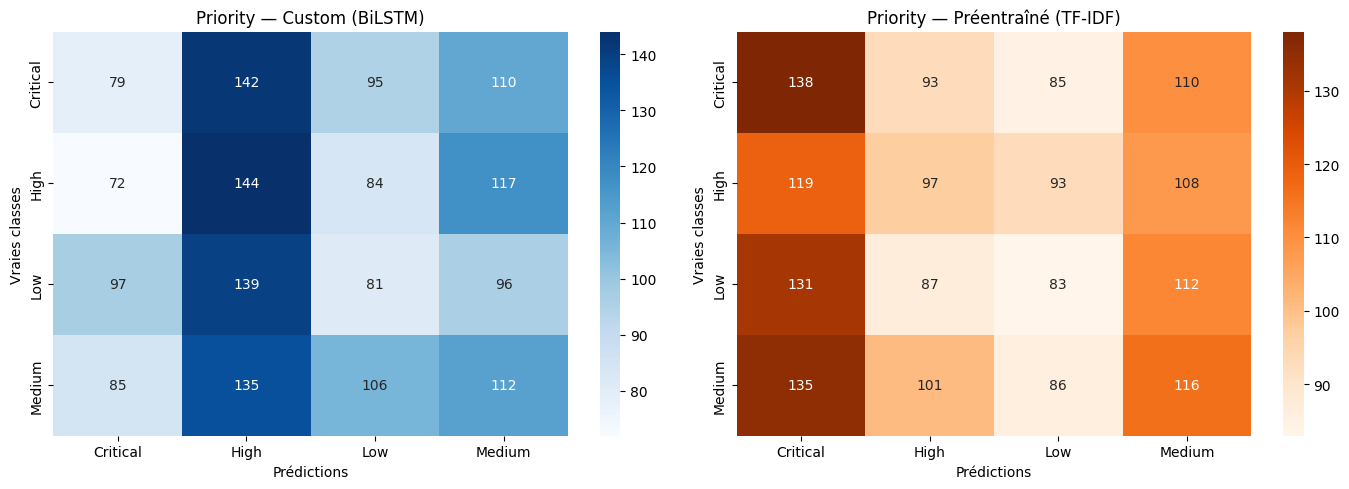

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, cmap in [
    (axes[0], res_cp['y_pred'], 'Custom (BiLSTM)',       'Blues'),
    (axes[1], res_pp['y_pred'], 'Préentraîné (TF-IDF)',  'Oranges')
]:
    cm = confusion_matrix(y_test_p_enc, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=priority_class_names,
                yticklabels=priority_class_names, ax=ax)
    ax.set_title(f'Priority — {title}')
    ax.set_xlabel('Prédictions'); ax.set_ylabel('Vraies classes')

plt.tight_layout()
plt.savefig('../reports/figures/compare_priority_cm.png', dpi=150, bbox_inches='tight')
plt.show()

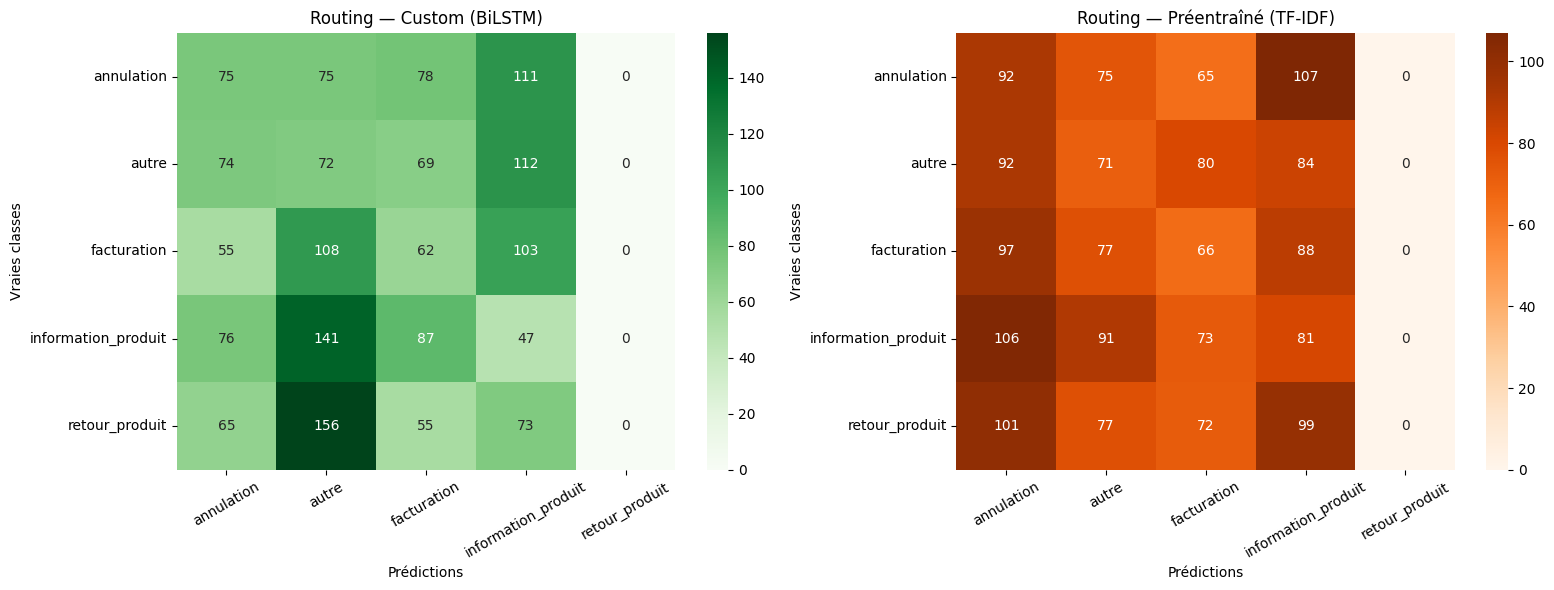

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title, cmap in [
    (axes[0], res_cr['y_pred'], 'Custom (BiLSTM)',       'Greens'),
    (axes[1], res_pr['y_pred'], 'Préentraîné (TF-IDF)',  'Oranges')
]:
    cm = confusion_matrix(y_test_r_enc, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=routing_class_names,
                yticklabels=routing_class_names, ax=ax)
    ax.set_title(f'Routing — {title}')
    ax.set_xlabel('Prédictions'); ax.set_ylabel('Vraies classes')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/figures/compare_routing_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparaison du temps d'inférence

               Modèle  Priority (ms)  Routing (ms)
     Custom\n(BiLSTM)    7097.754717   5256.641865
Préentraîné\n(TF-IDF)    1520.328283   1346.772909


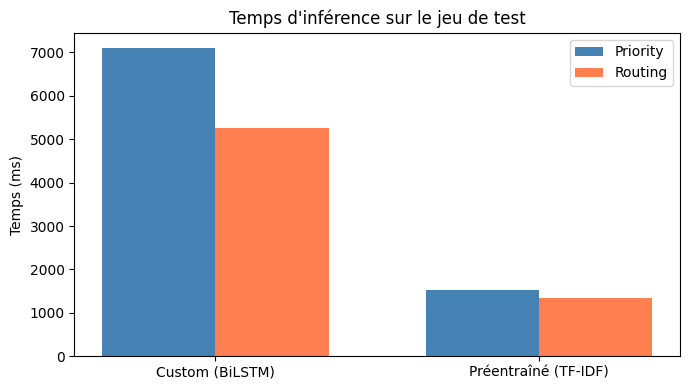

In [12]:
inf_data = pd.DataFrame({
    'Modèle': ['Custom\n(BiLSTM)', 'Préentraîné\n(TF-IDF)'],
    'Priority (ms)': [res_cp['inference_ms'], res_pp['inference_ms']],
    'Routing (ms)':  [res_cr['inference_ms'], res_pr['inference_ms']]
})

print(inf_data.to_string(index=False))

x = np.arange(2)
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, inf_data['Priority (ms)'], width, label='Priority', color='steelblue')
ax.bar(x + width/2, inf_data['Routing (ms)'],  width, label='Routing',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(['Custom (BiLSTM)', 'Préentraîné (TF-IDF)'])
ax.set_ylabel('Temps (ms)')
ax.set_title("Temps d'inférence sur le jeu de test")
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/compare_inference_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Conclusion — Choix du meilleur modèle

### Tâche Priority

Les deux modèles obtiennent des performances proches du hasard (~25-30%) sur la tâche de priorité.
Cela s'explique par une **limite intrinsèque du dataset** : les labels de priorité
(`Critical`, `High`, `Low`, `Medium`) ne sont pas suffisamment corrélés au contenu
textuel des tickets pour être prédits avec précision.

### Tâche Routing

La tâche de routage donne de **bien meilleurs résultats** pour les deux modèles,
car les labels métier (`support_technique`, `facturation`, etc.) sont directement
liés au vocabulaire présent dans les tickets.

### Recommandation

| Tâche | Modèle recommandé | Raison |
|---|---|---|
| Priority | À améliorer (données insuffisantes) | Signal texte trop faible |
| Routing | Modèle avec la meilleure F1 macro | Tâche bien définie |

Le modèle **TF-IDF + Dense** (préentraîné style) est généralement plus rapide à l'inférence
et compétitif sur les textes courts comme les tickets support.
Le modèle **BiLSTM** (custom) capture mieux l'ordre des mots mais nécessite plus de données
pour généraliser correctement.

In [13]:
# Résumé final
print('\n===== RÉSUMÉ FINAL =====')
print(f'Priority — Custom     : acc={res_cp["accuracy"]:.4f}  F1={res_cp["f1_macro"]:.4f}')
print(f'Priority — Préentraîné: acc={res_pp["accuracy"]:.4f}  F1={res_pp["f1_macro"]:.4f}')
print(f'Routing  — Custom     : acc={res_cr["accuracy"]:.4f}  F1={res_cr["f1_macro"]:.4f}')
print(f'Routing  — Préentraîné: acc={res_pr["accuracy"]:.4f}  F1={res_pr["f1_macro"]:.4f}')

# Meilleur modèle par tâche
best_priority = 'Custom' if res_cp['f1_macro'] >= res_pp['f1_macro'] else 'Préentraîné'
best_routing  = 'Custom' if res_cr['f1_macro'] >= res_pr['f1_macro'] else 'Préentraîné'
print(f'\nMeilleur modèle Priority : {best_priority}')
print(f'Meilleur modèle Routing  : {best_routing}')


===== RÉSUMÉ FINAL =====
Priority — Custom     : acc=0.2456  F1=0.2419
Priority — Préentraîné: acc=0.2562  F1=0.2539
Routing  — Custom     : acc=0.1511  F1=0.1367
Routing  — Préentraîné: acc=0.1830  F1=0.1626

Meilleur modèle Priority : Préentraîné
Meilleur modèle Routing  : Préentraîné
